# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [7]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_615/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_615/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

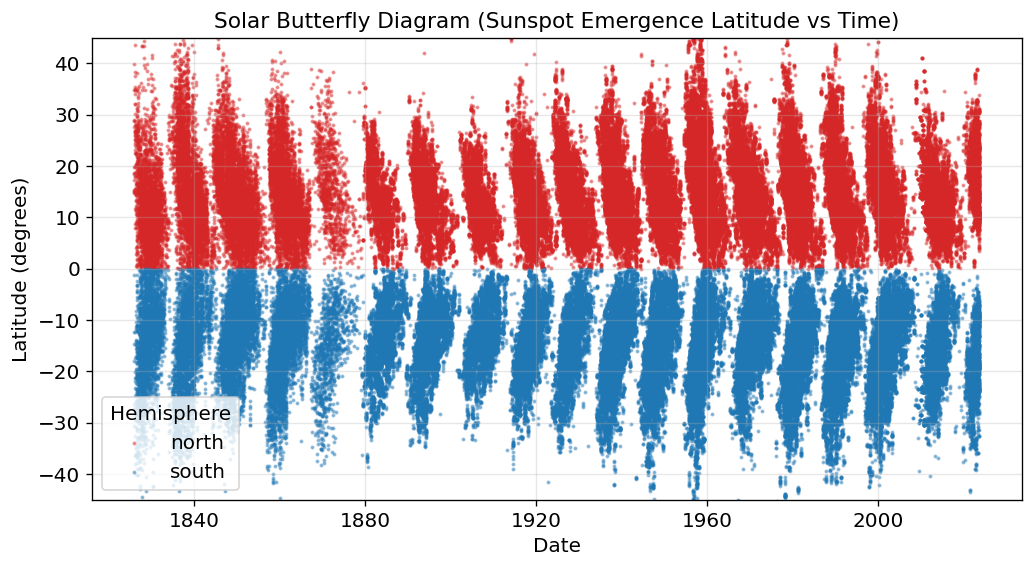

In [9]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


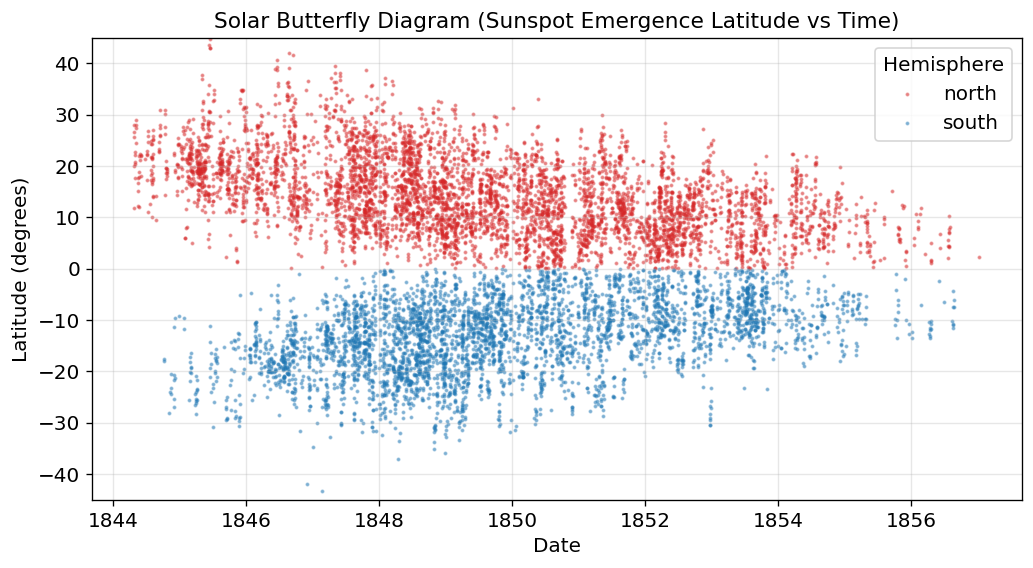

In [21]:
# Your code here: Visualize a single solar cycle

import matplotlib.pyplot as plt

cycle_number = 9    # data starts at cycle 7
single_cycle = df[df['CYCLE'] == cycle_number].copy()

single_cycle["hemisphere"] = single_cycle["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in single_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

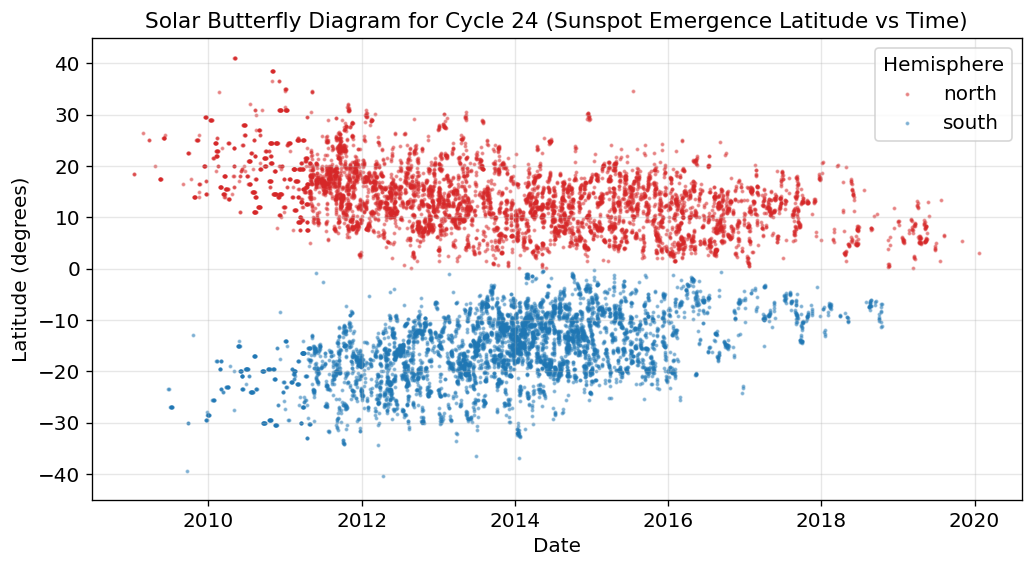

In [4]:
# Entire cell created by Gemini 2.5 Flash

import matplotlib.pyplot as plt

# Filter data for Cycle 24
cycle_24_df = df[df['CYCLE'] == 24].copy()

# Ensure the 'hemisphere' column is present in the filtered DataFrame
cycle_24_df["hemisphere"] = cycle_24_df["latitude"].apply(lambda v: "north" if v >= 0 else "south")

# Define colors for hemispheres
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in cycle_24_df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram for Cycle 24 (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


In [ ]:
# Your code here: Calculate and plot mean latitudinal paths


# need to find the mean latitude for each month

# the pd.read_csv has a parameter saying that the date should be parsed into datetime format upon reading, so we shouldn't need to confirm it like the AI does

# I find myself looking at the AI generated response to construct this one...

# I have never worked with pandas before, so there's that the AI is doing that I didn't know was possible in the first place

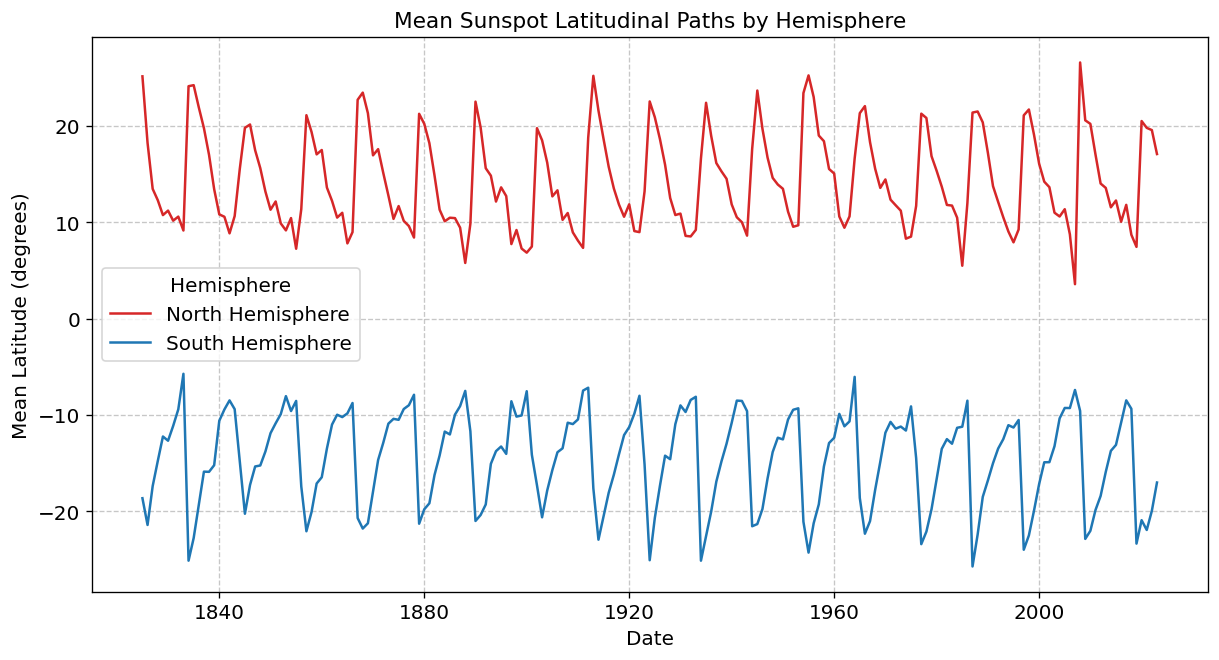

In [22]:
# Entire block created using Gemini 2.5 Flash

import matplotlib.pyplot as plt

# Ensure 'date' is datetime and 'hemisphere' is defined
df['date'] = pd.to_datetime(df['date'])
df['hemisphere'] = df['latitude'].apply(lambda v: 'north' if v >= 0 else 'south')

# Create a 'year_month' column for aggregation
df['year_month'] = df['date'].dt.to_period('M')

# Group by 'year_month' and 'hemisphere' and calculate the mean latitude
mean_lat_df = df.groupby(['year_month', 'hemisphere'])['latitude'].mean().reset_index()

# Convert 'year_month' back to datetime for plotting
mean_lat_df['date'] = mean_lat_df['year_month'].dt.to_timestamp()

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
colors = {'north': 'tab:red', 'south': 'tab:blue'}

for hemi, group in mean_lat_df.groupby('hemisphere'):
    ax.plot(group['date'], group['latitude'], color=colors[hemi], label=f'{hemi.capitalize()} Hemisphere')

ax.set_title('Mean Sunspot Latitudinal Paths by Hemisphere')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Latitude (degrees)')
ax.legend(title='Hemisphere')
ax.grid(True, linestyle='--', alpha=0.7)
plt.show()


Over each solar cycle the average latitude for a spot decreases. When the cycle starts spots appear at about 30 degrees latitude, and as the cycle ends the spots approach the equator.

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


# AI response:

That's a great question! To effectively prompt an AI assistant for learning machine learning and solar physics, consider these strategies:

Be Specific and Clear: Instead of a broad question like "Tell me about ML," ask "Explain the concept of backpropagation in neural networks, including its mathematical foundation and a simple example." For solar physics, "Describe the Parker Spiral and its implications for solar wind, using analogies if possible." Specify the depth and detail you're looking for.

Define Your Current Knowledge Level: Let the AI know what you already understand. For example, "I understand basic calculus, explain how gradient descent uses derivatives to optimize a loss function." Or, "I know about the Sun's magnetic field, but how does it lead to sunspots?"

Specify the Output Format: Do you want a summary, a step-by-step explanation, code examples, analogies, or a comparison table? "Provide a Python code example demonstrating k-means clustering with a small dataset." Or, "Compare and contrast the solar chromosphere and corona in a table format."

Ask for Analogies and Metaphors: These are excellent for grasping complex concepts. "Explain regularization in machine learning using a real-world analogy." Or, "Can you describe solar flares in terms of a physical phenomenon I might encounter on Earth?"

Request Elaboration or Simplification: If an explanation is too complex, ask, "Can you simplify that explanation further, assuming I'm a beginner?" If it's too basic, "Elaborate on the different types of solar oscillations and their observational techniques."

Ask for Problem-Solving Steps: For practical learning, ask the AI to walk you through solving a problem. "Walk me through the process of setting up a logistic regression model in scikit-learn, from data loading to evaluation." Or, "Describe the steps scientists take to predict solar energetic particle events."

Iterate and Refine: If the first answer isn't quite what you needed, follow up with clarifying questions. "You mentioned 'feature engineering.' Can you give me three common techniques used in machine learning?" Or, "Regarding sunspots, what causes their darker appearance compared to the rest of the photosphere?"

Contextualize Your Learning: If you're working on a project, tell the AI. "I'm trying to build a solar flare prediction model. What machine learning techniques are commonly used for time series forecasting in this domain?"

Ask for Resources: "What are some reputable online courses or textbooks for learning advanced topics in solar physics?" or "Suggest some academic papers on the latest advancements in explainable AI."

By being deliberate and detailed in your prompts, you can guide the AI to provide much more targeted and effective learning support. I'll definitely keep these tips in mind as we continue working together in these notebooks!


# My reflection:

AI works better the more specific the prompt is. This could be considered similar to humans as well; if you asked an expert in plasma physics how the magnetic field affects the velocity of the plasma, they would need to judge your experience and try to form a response that would be reasonable. The same can be said for AI, you must ask it precisely what you want to know.

To make the most of an AI assistant in this program, I will apply a classic approach:

1. Understand the setting of the problem. What is given, what am I expected to know, what do I need to research in order to even understand the problem in the first place.
2. Define the problem. What do I need to create?
3. Solve the problem.

I will likely be applying AI to this approach in two ways
1. Doing all three parts on my own, then having the AI do each part and comparing my result with the AI's result
2. Use the AI to help me with each part. This would be if I'm having trouble understanding some of the background of the problem, or if I don't understand what I am being asked to create.

I am lucky to have a bit of experience in solar physics, so I expect to be able to apply the first approach (comparing my result to the AI's result). However, I am sure that I will run into situations where I need help understanding something, which is when I will consult with the AI (and then sign up for office hours if the AI response is not satisfactory).

